**DL Assignment 10**

Name: Kuber Kishore <br>
Class: TY CSAI - A <br>
Batch: 3 <br>
Roll No.: 57 <br>
Date: 14-04-2026 <br>


---


**Problem Statement:** <br>
Using LSTM for prediction of future weather of cities in Python.

---



# Import libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM

# Load dataset

In [ ]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv"
data = pd.read_csv(url)

print(data.head())

# Use only temperature column
temp_data = data['Temp'].values.reshape(-1, 1)

         Date  Temp
0  1981-01-01  20.7
1  1981-01-02  17.9
2  1981-01-03  18.8
3  1981-01-04  14.6
4  1981-01-05  15.8


# Normalize data

In [ ]:
scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(temp_data)

# Create sequences

In [ ]:
def create_dataset(dataset, time_step=30):
    X, Y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        Y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(Y)

time_step = 30
X, y = create_dataset(scaled_data, time_step)

# Reshape for LSTM

In [ ]:
X = X.reshape(X.shape[0], X.shape[1], 1)

# Train-Test Split

In [ ]:
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Build LSTM model

In [ ]:
model = Sequential()

model.add(LSTM(50, return_sequences=True, input_shape=(time_step,1)))
model.add(LSTM(50))
model.add(Dense(1))

model.compile(loss='mean_squared_error', optimizer='adam')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


# Train model

In [ ]:
history = model.fit(X_train, y_train,
                    validation_data=(X_test, y_test),
                    epochs=20, batch_size=32)

Epoch 1/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 6s 33ms/step - loss: 0.0198 - val_loss: 0.0107
Epoch 2/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0118 - val_loss: 0.0099
Epoch 3/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0119 - val_loss: 0.0099
Epoch 4/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 5s 31ms/step - loss: 0.0116 - val_loss: 0.0096
Epoch 5/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0117 - val_loss: 0.0095
Epoch 6/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0114 - val_loss: 0.0093
Epoch 7/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0114 - val_loss: 0.0092
Epoch 8/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 4s 43ms/step - loss: 0.0109 - val_loss: 0.0090
Epoch 9/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0110 - val_loss: 0.0089
Epoch 10/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - loss: 0.0103 - val_loss: 0.0088
Epoch 11/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0101 - val_loss: 0.0095
Epoch 12/20
91/91 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - loss: 0.0

# Predictions

In [ ]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

# Reverse scaling
train_predict = scaler.inverse_transform(train_predict)
test_predict = scaler.inverse_transform(test_predict)

y_train_actual = scaler.inverse_transform(y_train.reshape(-1,1))
y_test_actual = scaler.inverse_transform(y_test.reshape(-1,1))

91/91 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


# Plot Results

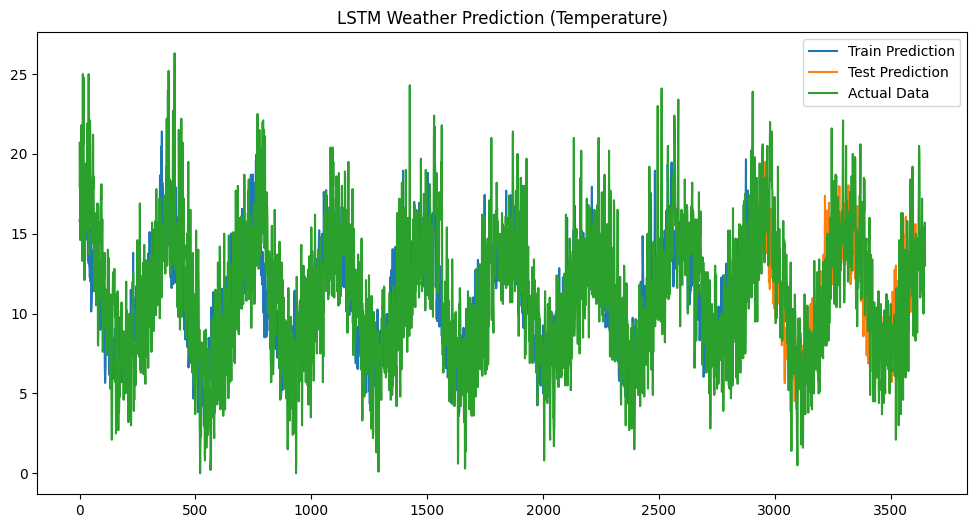

In [ ]:
plt.figure(figsize=(12,6))

# Train predictions
plt.plot(range(len(train_predict)), train_predict, label='Train Prediction')

# Test predictions
plt.plot(range(len(train_predict), len(train_predict)+len(test_predict)),
         test_predict, label='Test Prediction')

# Actual data
plt.plot(temp_data, label='Actual Data')

plt.legend()
plt.title("LSTM Weather Prediction (Temperature)")
plt.show()


# Predict future values

In [ ]:
future_days = 7
last_data = scaled_data[-time_step:]
future_predictions = []

input_seq = last_data.reshape(1, time_step, 1)

for _ in range(future_days):
    next_val = model.predict(input_seq)[0][0]
    future_predictions.append(next_val)

    input_seq = np.append(input_seq[:,1:,:], [[[next_val]]], axis=1)

# Convert back to original scale
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1,1))

print("Future Temperature Predictions (Next 7 Days):")
print(future_predictions)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Future Temperature Predictions (Next 7 Days):
[[12.948654]
 [13.202471]
 [13.298204]
 [13.301697]
 [13.26292 ]
 [13.211456]
 [13.160521]]


# Plot future predictions

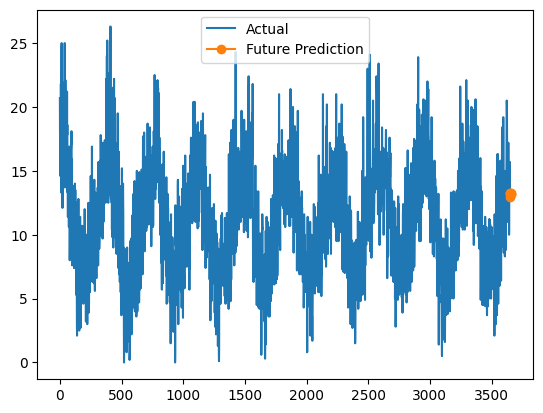

In [ ]:
plt.plot(range(len(temp_data)), temp_data, label="Actual")
plt.plot(range(len(temp_data), len(temp_data)+future_days),
         future_predictions, label="Future Prediction", marker='o')

plt.legend()
plt.show()